<a href="https://colab.research.google.com/github/matstabel/deep_learning/blob/main/TensorFlow_PyTorch_examplesfromclass_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# End-to-End Examples in TensorFlow and PyTorch

This notebook extracts the relevant [code from the notebook](https://colab.research.google.com/github/fchollet/deep-learning-with-python-notebooks/blob/master/chapter03_introduction-to-ml-frameworks.ipynb) from Deep Learning with Python, 3rd edition, Chapter 3. It also adds some explanations and completes the PyTorch example with an actual training loop.

# TensorFlow

## Generate data

We generate a synthetic dataset for a binary classification problem by drawing two groups of two-dimensional points from normal distributions. One group is centered around (0, 3) and represents the negative class, while the other is centered around (3, 0) and represents the positive class. We then stack these two groups into a single input matrix with 2000 observations and create a corresponding target vector where the first group is labeled 0 and the second group is labeled 1. In this way, we obtain two partially overlapping clusters that can be used to train and evaluate a classifier.

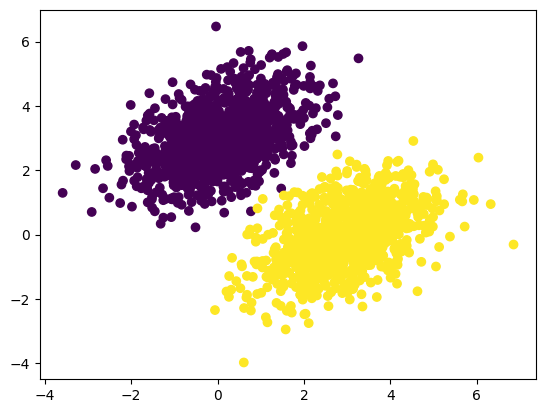

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


num_samples_per_class = 1000
negative_samples = np.random.multivariate_normal(
    mean=[0, 3], cov=[[1, 0.5], [0.5, 1]], size=num_samples_per_class
)
positive_samples = np.random.multivariate_normal(
    mean=[3, 0], cov=[[1, 0.5], [0.5, 1]], size=num_samples_per_class
)

inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)

targets = np.vstack(
    (
        np.zeros((num_samples_per_class, 1), dtype="float32"),
        np.ones((num_samples_per_class, 1), dtype="float32"),
    )
)


plt.scatter(inputs[:, 0], inputs[:, 1], c=targets[:, 0])
plt.show()

## Build the model

We define a simple linear model by specifying the number of input features (2) and the number of outputs (1). We then initialize the model parameters: a weight matrix $W$, which maps the two input features to a single output and is filled with random values, and a bias term $b$, which is initialized to zero. Both $W$ and $b$ are defined as TensorFlow variables so they can be updated during training.

In [ ]:
import tensorflow as tf

input_dim = 2
output_dim = 1
W = tf.Variable(initial_value=tf.random.uniform(shape=(input_dim, output_dim)))
b = tf.Variable(initial_value=tf.zeros(shape=(output_dim,)))

We define a simple linear model that takes the input data and computes a weighted sum using the weight matrix $W$ and bias $b$. Specifically, we multiply the inputs by $W$ and then add $b$, producing a single output for each observation. This output represents the model’s prediction before any transformation is applied.

In [ ]:
def model(inputs, W, b):
    return tf.matmul(inputs, W) + b

We define the mean squared error loss function, which measures how far the model's predictions are from the true target values. For each observation, we compute the squared difference between the target and the prediction, and then we take the average across all observations. This gives a single number that summarizes how well the model is performing.

In [ ]:
def mean_squared_error(targets, predictions):
    per_sample_losses = tf.square(targets - predictions)
    return tf.reduce_mean(per_sample_losses)

We define a single training step that updates the model parameters using gradient descent. First, we compute the model’s predictions and the loss inside a gradient tape, which records how the loss depends on the parameters $W$ and $b$. We then compute the gradients of the loss with respect to $W$ and $b$, which tell us how a small change in each parameter would affect the loss. Finally, we update the parameters by moving them slightly in the direction that reduces the loss, using the learning rate to control the step size. The function returns the current value of the loss.

In [ ]:
learning_rate = 0.1

@tf.function(jit_compile=True)
def training_step(inputs, targets, W, b):
    with tf.GradientTape() as tape:
        predictions = model(inputs, W, b)
        loss = mean_squared_error(predictions, targets)
    grad_loss_wrt_W, grad_loss_wrt_b = tape.gradient(loss, [W, b])
    W.assign_sub(grad_loss_wrt_W * learning_rate)
    b.assign_sub(grad_loss_wrt_b * learning_rate)
    return loss

We run the training step repeatedly for 40 iterations. In each iteration, we update the model parameters $W$ and $b$ based on the current data and compute the loss. After each update, we print the loss value to monitor how the model improves over time. As training progresses, we expect the loss to decrease as the model fits the data better.

In [ ]:
for step in range(40):
    loss = training_step(inputs, targets, W, b)
    print(f"Loss at step {step}: {loss:.4f}")

Loss at step 0: 3.2100
Loss at step 1: 0.4679
Loss at step 2: 0.1749
Loss at step 3: 0.1323
Loss at step 4: 0.1196
Loss at step 5: 0.1111
Loss at step 6: 0.1036
Loss at step 7: 0.0968
Loss at step 8: 0.0907
Loss at step 9: 0.0850
Loss at step 10: 0.0799
Loss at step 11: 0.0752
Loss at step 12: 0.0709
Loss at step 13: 0.0670
Loss at step 14: 0.0634
Loss at step 15: 0.0601
Loss at step 16: 0.0571
Loss at step 17: 0.0544
Loss at step 18: 0.0519
Loss at step 19: 0.0496
Loss at step 20: 0.0476
Loss at step 21: 0.0457
Loss at step 22: 0.0439
Loss at step 23: 0.0423
Loss at step 24: 0.0409
Loss at step 25: 0.0396
Loss at step 26: 0.0384
Loss at step 27: 0.0373
Loss at step 28: 0.0363
Loss at step 29: 0.0354
Loss at step 30: 0.0345
Loss at step 31: 0.0338
Loss at step 32: 0.0331
Loss at step 33: 0.0324
Loss at step 34: 0.0318
Loss at step 35: 0.0313
Loss at step 36: 0.0308
Loss at step 37: 0.0304
Loss at step 38: 0.0300
Loss at step 39: 0.0296


Let's plot the data and the linear classifier

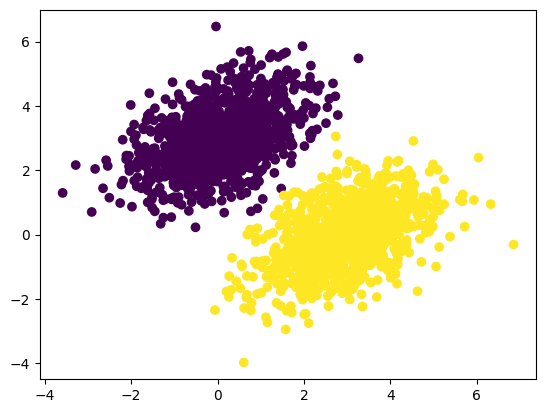

In [ ]:
predictions = model(inputs, W, b)
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)
plt.show()

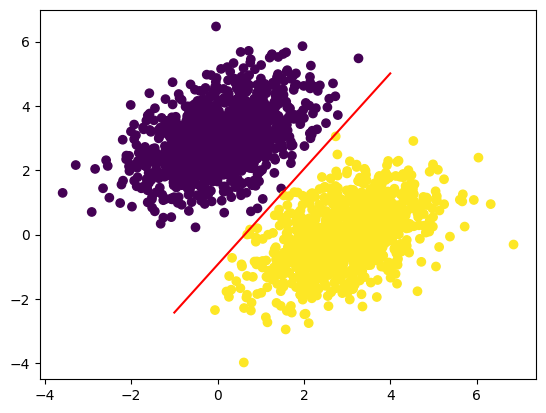

In [ ]:
x = np.linspace(-1, 4, 100)
y = -W[0] / W[1] * x + (0.5 - b) / W[1]
plt.plot(x, y, "-r")
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)

#PyTorch

Let's do the exact same thing in PyTorch. Again, initialize the parameters we going to learn by training.

In [ ]:
import torch

Same model and same loss as before

In [ ]:
def model(inputs, W, b):
    return torch.matmul(inputs, W) + b

def mean_squared_error(targets, predictions):
    per_sample_losses = torch.square(targets - predictions)
    return torch.mean(per_sample_losses)

We define a simple linear model in PyTorch by creating a custom module that contains the model parameters $W$ and $b$. This makes everything a simpler in a bit.

We define a simple linear model in PyTorch by creating a custom class that inherits from `torch.nn.Module`, which is the base class for all neural network models. The call to `super().__init__()` initializes the parent class and ensures that PyTorch can properly track the model and its parameters. Inside the model, we define two learnable parameters: a weight matrix $W$, initialized with random values, and a bias term $b$, initialized to zero. These are wrapped as `torch.nn.Parameter`, which tells PyTorch that they should be updated during training. In the `forward` method, we specify how the model produces predictions by computing the linear combination $XW + b$. Finally, we create an instance of the model, which can then be used for training.

In [ ]:
input_dim = 2
output_dim = 1

class LinearModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.W = torch.nn.Parameter(torch.rand(input_dim, output_dim))
        self.b = torch.nn.Parameter(torch.zeros(output_dim))

    def forward(self, inputs):
        return torch.matmul(inputs, self.W) + self.b

model = LinearModel()

In [ ]:
torch_inputs = torch.tensor(inputs)

Pull out an SGD optimizer from the Torch library and use the same learning rate as before

In [ ]:
learning_rate = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

We define a single training step for the PyTorch model. First, we pass the inputs through the model to obtain predictions and compute the loss by comparing the predictions to the targets. We then call `loss.backward()`, which automatically computes the gradients of the loss with respect to all model parameters such as $W$ and $b$. Next, `optimizer.step()` updates the parameters in the direction that reduces the loss. Finally, we reset the gradients using `model.zero_grad()` to avoid accumulating gradients across iterations. The function returns the current loss value so we can monitor training progress.

Notice:

*   No `GradientTape`:  we run `loss.backward` through all operations previously executed that led to that tensor



In [ ]:
def training_step(inputs, targets):
    predictions = model(inputs)
    loss = mean_squared_error(targets, predictions)
    loss.backward()
    optimizer.step()
    model.zero_grad()
    return loss

Before we actually do the training steps, we need to convert to PyTorch tensors

In [ ]:
# Convert NumPy arrays to PyTorch tensors
torch_inputs = torch.tensor(inputs)
torch_targets = torch.tensor(targets)

Let's loop! We run the training loop for 40 iterations, where each iteration performs one update of the model parameters. At the start of each step, we clear any previously stored gradients using `optimizer.zero_grad()`. We then compute the model's predictions from the inputs and evaluate the loss by comparing predictions to the targets. Calling `loss.backward()` computes the gradients of the loss with respect to the model parameters, and `optimizer.step()` updates those parameters in the direction that reduces the loss. After each step, we print the loss value to track how the model improves over time.

In [ ]:
for step in range(40):
    optimizer.zero_grad()
    predictions = model(torch_inputs)
    loss = mean_squared_error(torch_targets, predictions)
    loss.backward()
    optimizer.step()

    print(f"Loss at step {step}: {loss.item():.4f}")

Loss at step 0: 0.4622
Loss at step 1: 0.1403
Loss at step 2: 0.1011
Loss at step 3: 0.0912
Loss at step 4: 0.0851
Loss at step 5: 0.0799
Loss at step 6: 0.0752
Loss at step 7: 0.0709
Loss at step 8: 0.0670
Loss at step 9: 0.0634
Loss at step 10: 0.0601
Loss at step 11: 0.0571
Loss at step 12: 0.0544
Loss at step 13: 0.0519
Loss at step 14: 0.0496
Loss at step 15: 0.0476
Loss at step 16: 0.0457
Loss at step 17: 0.0439
Loss at step 18: 0.0424
Loss at step 19: 0.0409
Loss at step 20: 0.0396
Loss at step 21: 0.0384
Loss at step 22: 0.0373
Loss at step 23: 0.0363
Loss at step 24: 0.0354
Loss at step 25: 0.0345
Loss at step 26: 0.0338
Loss at step 27: 0.0331
Loss at step 28: 0.0324
Loss at step 29: 0.0318
Loss at step 30: 0.0313
Loss at step 31: 0.0308
Loss at step 32: 0.0304
Loss at step 33: 0.0300
Loss at step 34: 0.0296
Loss at step 35: 0.0293
Loss at step 36: 0.0290
Loss at step 37: 0.0287
Loss at step 38: 0.0284
Loss at step 39: 0.0282


Plot - like before only with prettier colors :)

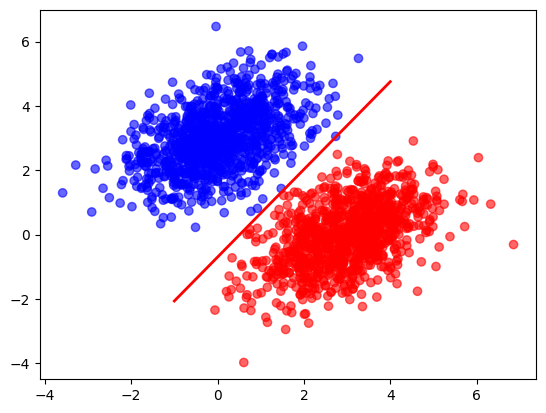

In [ ]:
with torch.no_grad():
    predictions = model(torch_inputs).numpy()

W = model.W.detach().numpy().flatten()
b = model.b.detach().numpy()[0]

plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5, cmap="bwr", alpha=0.6)

x = np.linspace(-1, 4, 100)
y = -(W[0] / W[1]) * x + (0.5 - b) / W[1]

plt.plot(x, y, "-r", linewidth=2)
plt.show()